# VAE Portfolio Project - Scenario Generation

This notebook generates market scenarios using the trained VAE.

In [57]:
# Import libraries
import sys
sys.path.append('../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from vae_model import VAE
from utils import denormalize_data, torch_to_numpy, PortfolioConfig, sample_stressed_latent, select_top_stressed_scenarios

plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {device}")

Device: cpu


## 1. Load Trained VAE Model

In [58]:

# Load model
checkpoint = torch.load('../results/vae_model.pth', map_location=device,weights_only=False)

config = checkpoint['config']
if not hasattr(config, 'stress_tail_fraction'):
    config.stress_tail_fraction = 0.1
scaler = checkpoint['scaler']

# Recreate model
input_dim = 4  # Number of indices
vae = VAE(input_dim=input_dim, latent_dim=config.latent_dim, hidden_dim=config.hidden_dim)
vae.load_state_dict(checkpoint['model_state'])
vae = vae.to(device)
vae.eval()

print(f"Model loaded successfully!")
print(f"Latent dimension: {config.latent_dim}")

Model loaded successfully!
Latent dimension: 10


## 2. Generate Scenarios

In [59]:
# Generate scenarios
n_scenarios = config.n_scenarios
n_candidates = max(n_scenarios * 5, 5000)
stress_std_scale = 1.8
stress_tail_fraction = config.stress_tail_fraction

print(f"Generating {n_candidates} candidate scenarios in a stressed latent distribution...")

with torch.no_grad():
    # standard (unbiased) generated scenarios used elsewhere in the notebook
    scenarios_normalized = vae.generate_samples(n_scenarios, device=device)
    scenarios_normalized = torch_to_numpy(scenarios_normalized)

    # stressed candidates for selection
    z_candidates = sample_stressed_latent(
        n_samples=n_candidates,
        latent_dim=config.latent_dim,
        std_scale=stress_std_scale,
        device=device,
    )
    scenarios_candidates_normalized = vae.decode(z_candidates)
    scenarios_candidates_normalized = torch_to_numpy(scenarios_candidates_normalized)

print(f"Candidate scenarios shape: {scenarios_candidates_normalized.shape}")
print(f"Candidate mean: {scenarios_candidates_normalized.mean():.6f}")
print(f"Candidate std: {scenarios_candidates_normalized.std():.6f}")
print(f"Stress tail fraction: {stress_tail_fraction}")

weights = config.weights / config.weights.sum()
selected_stressed_normalized, stressed_portfolio_returns, stress_scores = select_top_stressed_scenarios(
    scenarios_candidates_normalized,
    weights=weights,
    top_k=n_scenarios,
)

print(f"\nSelected stressed scenarios shape: {selected_stressed_normalized.shape}")
print(f"Selected portfolio return mean: {stressed_portfolio_returns.mean():.6f}")
print(f"Selected portfolio return std: {stressed_portfolio_returns.std():.6f}")
print(f"Selected stress score mean: {stress_scores.mean():.6f}")

Generating 50000 candidate scenarios in a stressed latent distribution...
Candidate scenarios shape: (50000, 4)
Candidate mean: -0.015007
Candidate std: 1.807127
Stress tail fraction: 0.1

Selected stressed scenarios shape: (10000, 4)
Selected portfolio return mean: -2.083600
Selected portfolio return std: 1.073479
Selected stress score mean: 2.083600


In [60]:
# Denormalize scenarios
scenarios = denormalize_data(scenarios_normalized, scaler)

# Create DataFrame
indices = config.indices
scenarios_df = pd.DataFrame(scenarios, columns=indices)

print(f"Denormalized scenarios shape: {scenarios_df.shape}")
print(f"\nScenarios summary:")
print(scenarios_df.describe())

Denormalized scenarios shape: (10000, 4)

Scenarios summary:
              ^GSPC     ^STOXX50E         ^N225          ^HSI
count  10000.000000  10000.000000  10000.000000  10000.000000
mean       0.000313      0.000460      0.000769      0.000584
std        0.008927      0.010278      0.011078      0.011068
min       -0.095614     -0.058889     -0.060471     -0.072288
25%       -0.002900     -0.004615     -0.004794     -0.004118
50%        0.000937      0.000987      0.001175      0.001177
75%        0.004741      0.006297      0.006715      0.006367
max        0.051042      0.052405      0.056024      0.046392


In [61]:
# Denormalize stressed scenarios
selected_stressed = denormalize_data(selected_stressed_normalized, scaler)
selected_stressed_df = pd.DataFrame(selected_stressed, columns=indices)

print(f"Selected stressed scenarios shape: {selected_stressed_df.shape}")
print(f"\nSelected stressed scenarios summary:")
print(selected_stressed_df.describe())

Selected stressed scenarios shape: (10000, 4)

Selected stressed scenarios summary:
              ^GSPC     ^STOXX50E         ^N225          ^HSI
count  10000.000000  10000.000000  10000.000000  10000.000000
mean      -0.027897     -0.023904     -0.025912     -0.031559
std        0.023089      0.019935      0.025210      0.025323
min       -0.153644     -0.154274     -0.153556     -0.170533
25%       -0.040742     -0.035759     -0.040340     -0.045698
50%       -0.024665     -0.021527     -0.023457     -0.028453
75%       -0.012304     -0.009719     -0.009669     -0.014413
max        0.043615      0.030262      0.063263      0.049114


## 3. Load Historical Returns for Comparison

In [62]:
# Load historical returns
historical_returns = pd.read_csv('../data/returns.csv', index_col=0)

print(f"Historical returns shape: {historical_returns.shape}")
print(f"\nHistorical summary:")
print(historical_returns.describe())

Historical returns shape: (2001, 4)

Historical summary:
             ^GSPC         ^HSI        ^N225    ^STOXX50E
count  2001.000000  2001.000000  2001.000000  2001.000000
mean      0.000429    -0.000165     0.000327     0.000201
std       0.012126     0.013915     0.013263     0.013163
min      -0.127652    -0.065673    -0.117658    -0.132405
25%      -0.004079    -0.007417    -0.006008    -0.005368
50%       0.000634     0.000228     0.000692     0.000777
75%       0.006106     0.007192     0.007174     0.006372
max       0.089683     0.086928     0.077314     0.088343


## 4. Compare Distributions

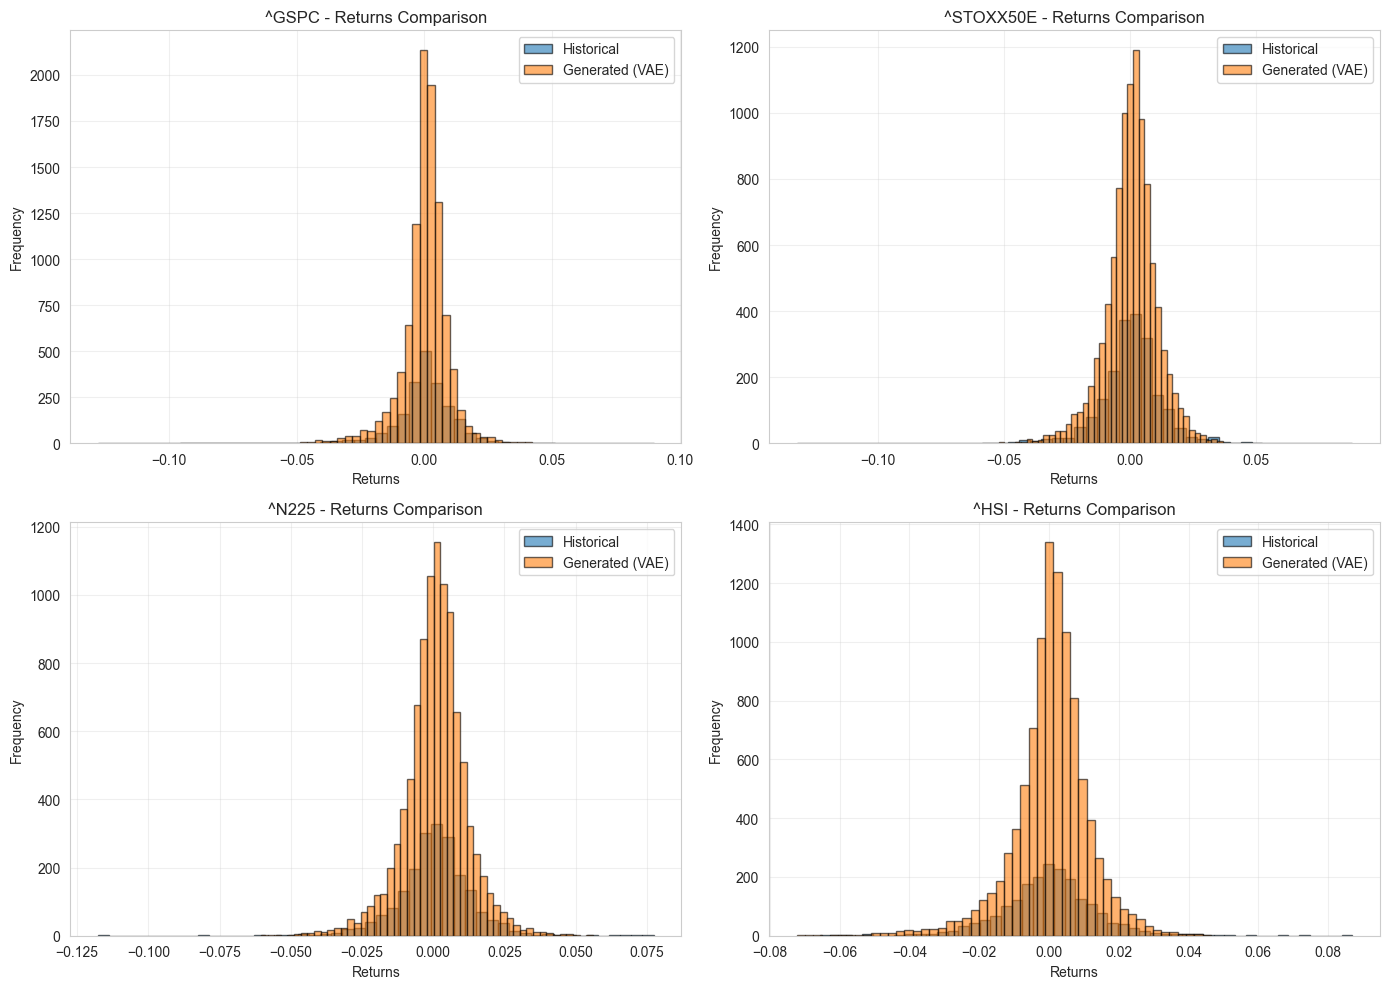

In [63]:
# Compare distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, col in enumerate(indices):
    # Plot historical
    axes[idx].hist(historical_returns[col], bins=50, alpha=0.6, label='Historical', edgecolor='black')
    
    # Plot generated
    axes[idx].hist(scenarios_df[col], bins=50, alpha=0.6, label='Generated (VAE)', edgecolor='black')
    
    axes[idx].set_title(f'{col} - Returns Comparison')
    axes[idx].set_xlabel('Returns')
    axes[idx].set_ylabel('Frequency')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/05_scenario_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

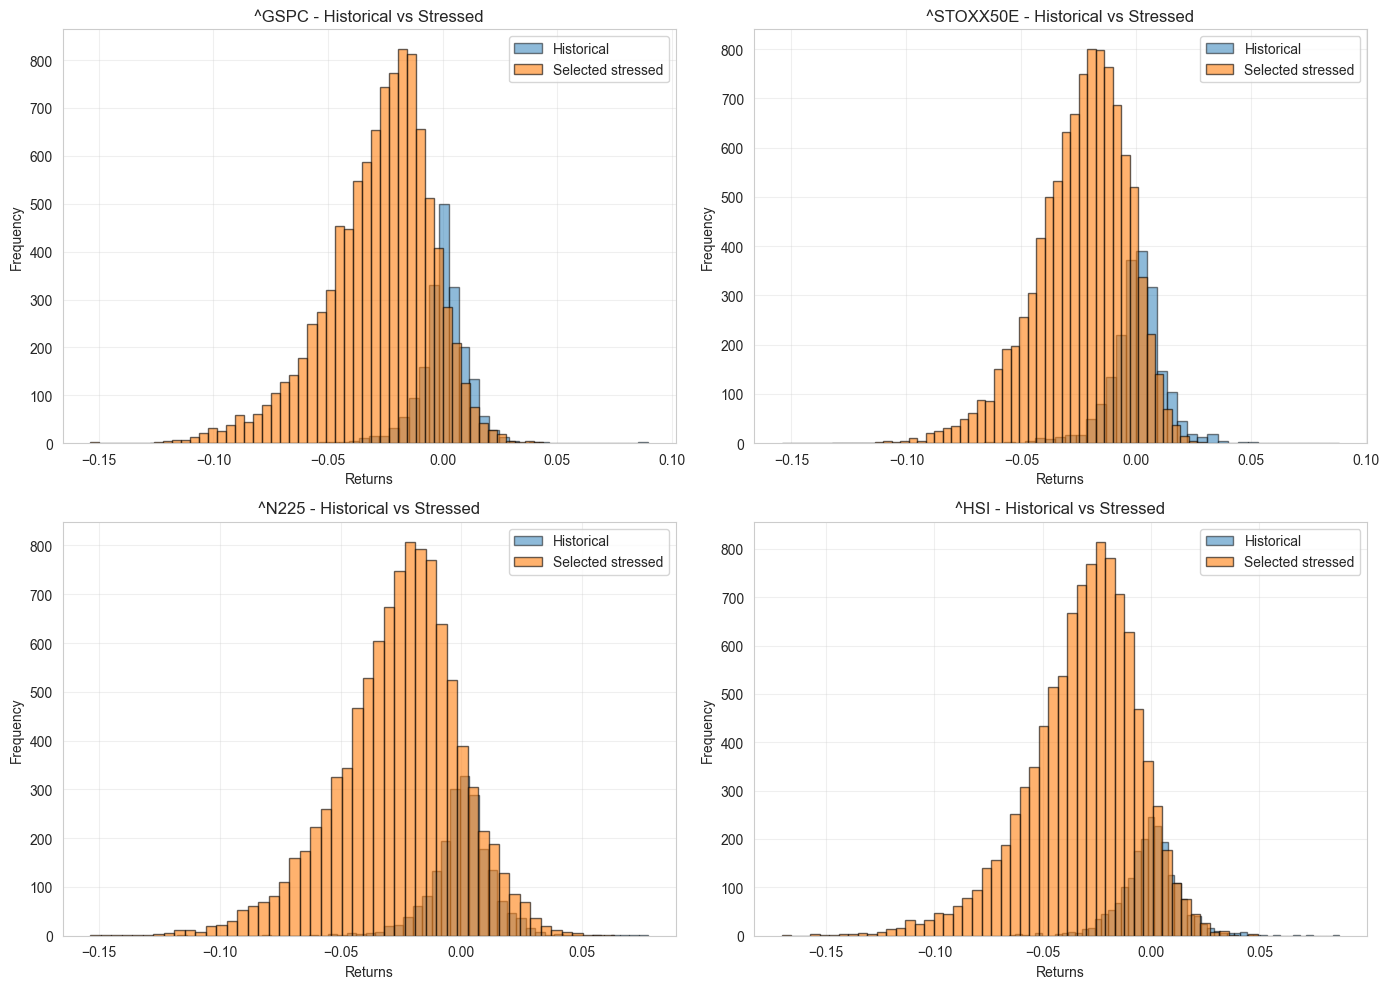

In [64]:
# Compare historical and stressed selected scenarios
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, col in enumerate(indices):
    axes[idx].hist(historical_returns[col], bins=50, alpha=0.5, label='Historical', edgecolor='black')
    axes[idx].hist(selected_stressed_df[col], bins=50, alpha=0.6, label='Selected stressed', edgecolor='black')
    axes[idx].set_title(f'{col} - Historical vs Stressed')
    axes[idx].set_xlabel('Returns')
    axes[idx].set_ylabel('Frequency')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/05_stressed_scenario_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Statistical Tests

In [65]:
from scipy import stats

# Kolmogorov-Smirnov test
print("Kolmogorov-Smirnov Test (H0: same distribution):")
print("-" * 60)

for col in indices:
    ks_stat, p_value = stats.ks_2samp(historical_returns[col], scenarios_df[col])
    print(f"{col:15} | KS-stat: {ks_stat:.4f} | p-value: {p_value:.4f}")

print("\nNote: Higher p-value means distributions are more similar")

Kolmogorov-Smirnov Test (H0: same distribution):
------------------------------------------------------------
^GSPC           | KS-stat: 0.0730 | p-value: 0.0000
^STOXX50E       | KS-stat: 0.0280 | p-value: 0.1433
^N225           | KS-stat: 0.0444 | p-value: 0.0027
^HSI            | KS-stat: 0.0959 | p-value: 0.0000

Note: Higher p-value means distributions are more similar


## 6. Calculate Portfolio Returns

In [66]:
# Portfolio weights
weights = config.weights / config.weights.sum()

print(f"Portfolio weights: {dict(zip(indices, weights))}")

# Calculate portfolio returns
historical_portfolio = np.dot(historical_returns.values, weights)
generated_portfolio = np.dot(scenarios_df.values, weights)

print(f"\nHistorical portfolio returns - Mean: {historical_portfolio.mean():.6f}, Std: {historical_portfolio.std():.6f}")
print(f"Generated portfolio returns  - Mean: {generated_portfolio.mean():.6f}, Std: {generated_portfolio.std():.6f}")

Portfolio weights: {'^GSPC': 0.4000000000000001, '^STOXX50E': 0.30000000000000004, '^N225': 0.20000000000000004, '^HSI': 0.10000000000000002}

Historical portfolio returns - Mean: 0.000208, Std: 0.009616
Generated portfolio returns  - Mean: 0.000475, Std: 0.008177


## 7. Plot Portfolio Returns

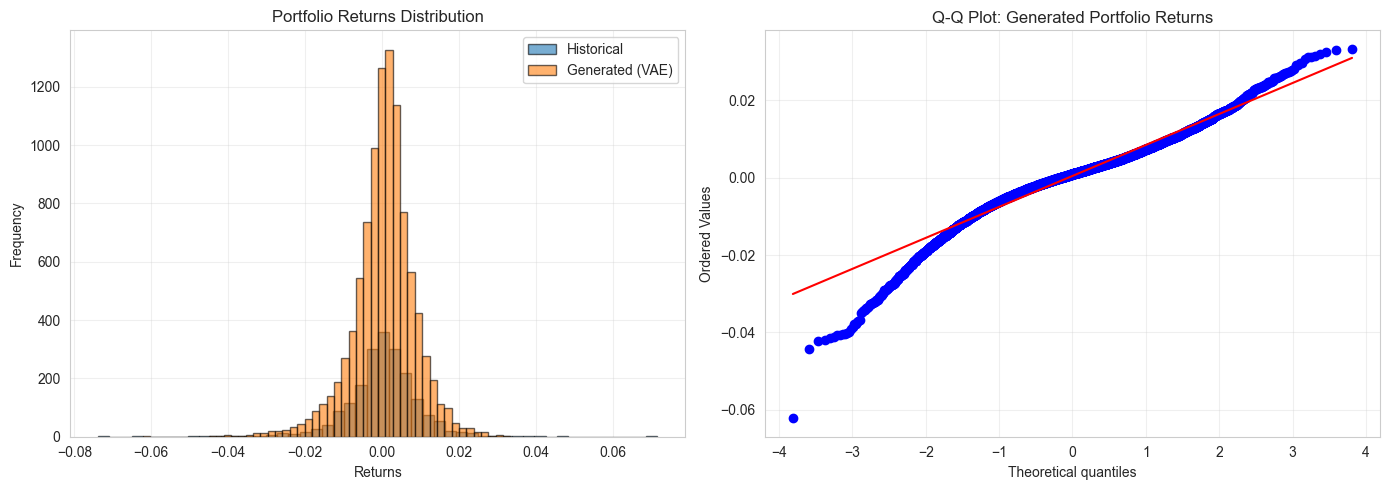

In [67]:
# Plot portfolio returns comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(historical_portfolio, bins=50, alpha=0.6, label='Historical', edgecolor='black')
axes[0].hist(generated_portfolio, bins=50, alpha=0.6, label='Generated (VAE)', edgecolor='black')
axes[0].set_title('Portfolio Returns Distribution')
axes[0].set_xlabel('Returns')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Q-Q plot
stats.probplot(generated_portfolio, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot: Generated Portfolio Returns')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/06_portfolio_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## 8. Save Scenarios for VaR Calculation

In [68]:
# Save scenarios
scenarios_df.to_csv('../results/scenarios.csv', index=False)

# Save portfolio returns (safe with mismatched lengths)
portfolio_data = pd.concat(
    [
        pd.Series(historical_portfolio, name='historical'),
        pd.Series(generated_portfolio, name='generated'),
    ],
    axis=1,
 )
portfolio_data.to_csv('../results/portfolio_returns.csv', index=False)

print("Scenarios saved!")
print(f"  - scenarios.csv: {scenarios_df.shape}")
print(f"  - portfolio_returns.csv: {portfolio_data.shape}")
print("  - Note: length mismatch handled with NaN padding")

Scenarios saved!
  - scenarios.csv: (10000, 4)
  - portfolio_returns.csv: (10000, 2)
  - Note: length mismatch handled with NaN padding
